In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [77]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]
print(df.head)

<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8  

In [78]:
#Bagian A - Eksplorasi Data Awal
# 1. Informasi Dataset
print("Jumlah data:", len(df))
print("Jumlah variabel:", df.shape[1]-1)
print("Tipe data variabel:")
print(df.dtypes)
print("Jumlah masing-masing spesies:")
print(df['species'].value_counts())

Jumlah data: 150
Jumlah variabel: 4
Tipe data variabel:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object
Jumlah masing-masing spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [79]:
# 2. Statistik Deskriptif
stat = df.describe(). loc[['mean', '50%', 'std', 'min', 'max']]
stat.rename(index={'50%':'median'}, inplace=True)
print(stat)

        sepal length (cm)  sepal width (cm)  petal length (cm)  \
mean             5.843333          3.057333           3.758000   
median           5.800000          3.000000           4.350000   
std              0.828066          0.435866           1.765298   
min              4.300000          2.000000           1.000000   
max              7.900000          4.400000           6.900000   

        petal width (cm)  
mean            1.199333  
median          1.300000  
std             0.762238  
min             0.100000  
max             2.500000  


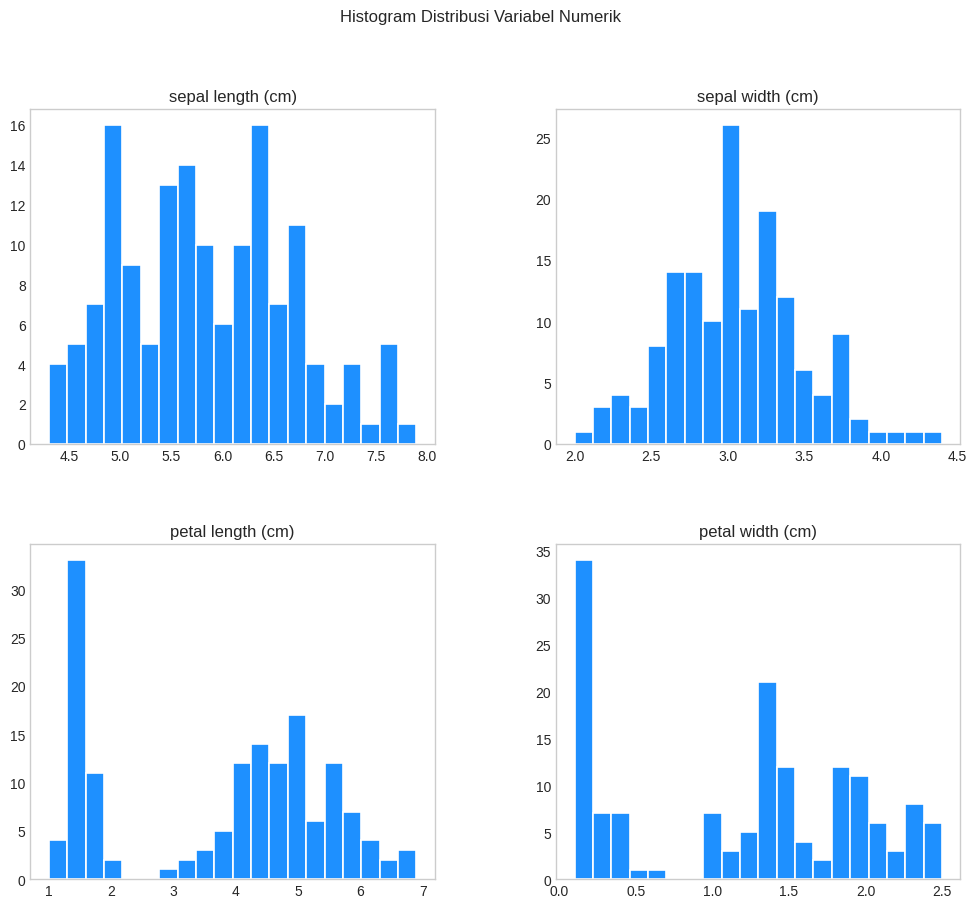

In [80]:
# 3. Visualisasi Distribusi
# a. Histogram
plt.style.use('seaborn-v0_8-whitegrid')
df.hist(figsize=(12, 10), color='dodgerblue', edgecolor='white', linewidth=1.2,
        bins=20, grid=False)
plt.suptitle("Histogram Distribusi Variabel Numerik")
plt.show()

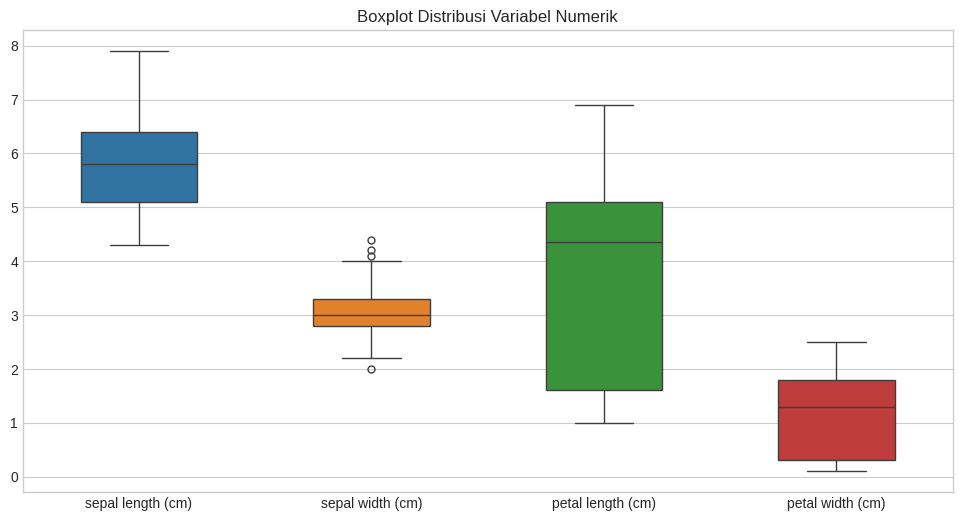

In [81]:
# b. Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df, width=0.5, fliersize=5)
plt.title("Boxplot Distribusi Variabel Numerik")
plt.show()



1.   Bentuk Distribusi
Berdasarkan histogram yang dibuat, terdapat dua pola utama. Variabel sepal (length & width) cenderung mengikuti distribusi normal atau simetris, di mana sebagian besar data mengumpul di tengah. Namun, pada variabel petal (length & width), bentuknya adalah bimodal (memiliki dua puncak). Puncak kecil di sebelah kiri mewakili spesies Setosa yang berukuran mini, sedangkan puncak besar di kanan adalah gabungan Versicolor dan Virginica.
2.   Sebaran Data
Variabel sepal width memiliki sebaran yang paling sempit atau konsisten (datanya mengumpul), sedangkan petal length memiliki sebaran yang paling luas (dari 1 cm hingga hampir 7 cm). Ini menunjukkan bahwa ukuran kelopak dalam (petal) jauh lebih bervariasi dibandingkan kelopak luar (sepal).
3. Adanya Outlier
Hanya ditemukan outlier pada variabel sepal width. Hal ini terlihat dari adanya titik-titik di luar garis kumis boxplot. Variabel lainnya seperti sepal length dan kedua variabel petal cenderung bersih dari pencilan, artinya variasi ukuran pada variabel tersebut masih dalam batas pertumbuhan yang wajar.



<function matplotlib.pyplot.show(close=None, block=None)>

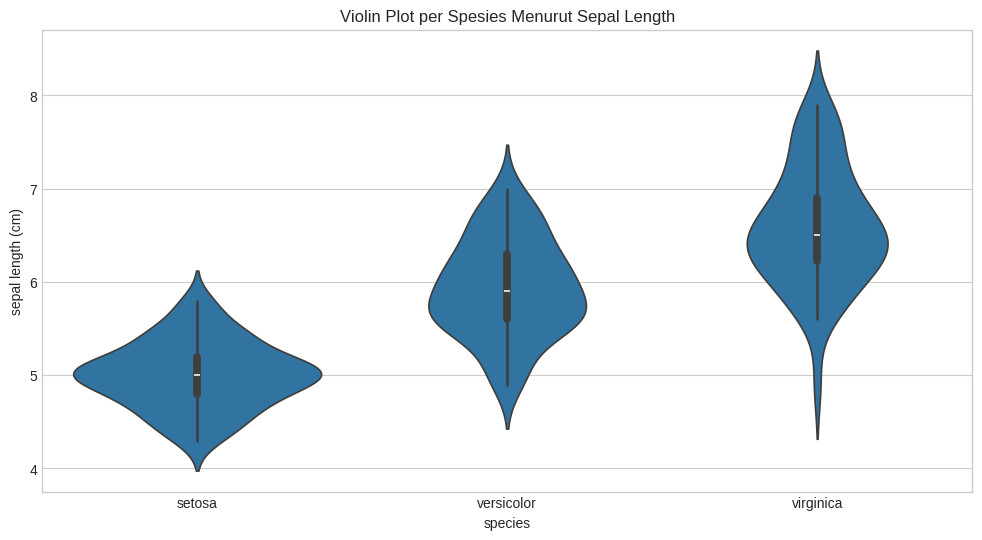

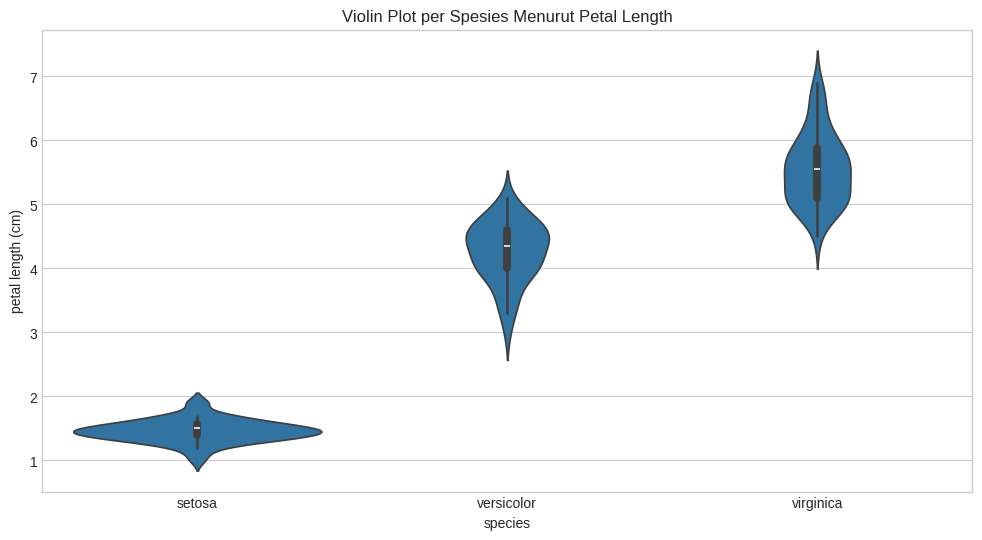

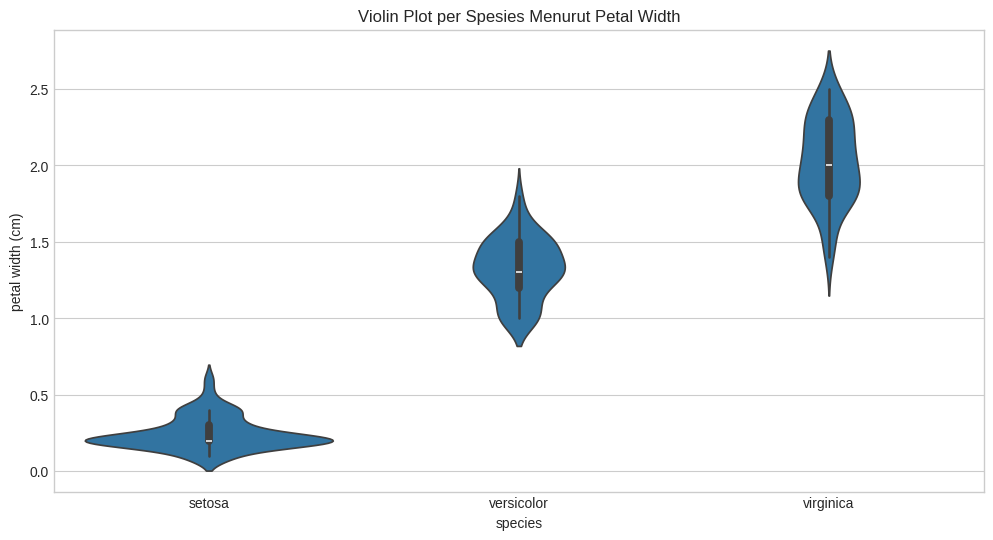

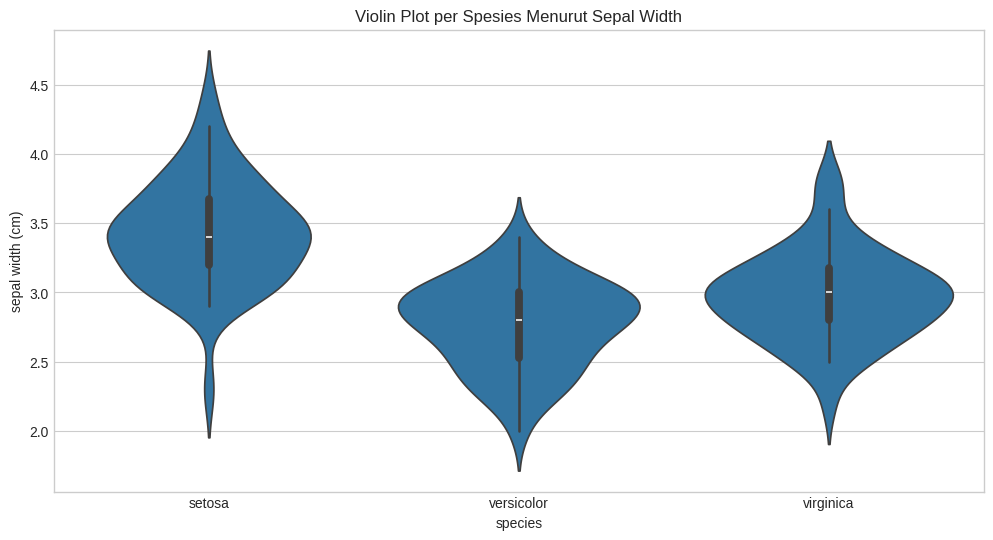

In [82]:
# 4. Visualisasi Berdasarkan Spesies
# Violin plot per spesies
plt.figure(figsize=(12,6))
sns.violinplot(x='species', y='sepal length (cm)', data=df)
plt.title("Violin Plot per Spesies Menurut Sepal Length")
plt.show
plt.figure(figsize=(12,6))
sns.violinplot(x='species', y='petal length (cm)', data=df)
plt.title("Violin Plot per Spesies Menurut Petal Length")
plt.show
plt.figure(figsize=(12,6))
sns.violinplot(x='species', y='petal width (cm)', data=df)
plt.title("Violin Plot per Spesies Menurut Petal Width")
plt.show
plt.figure(figsize=(12,6))
sns.violinplot(x='species', y='sepal width (cm)', data=df)
plt.title("Violin Plot per Spesies Menurut Sepal Width")
plt.show

Perbedaan antar spesies


1.   Iris Setosa memiliki nilai rata-rata (mean) terendah pada variabel petal length dan petal width. Analisis distribusi menunjukkan bahwa Setosa memiliki kepadatan data yang sangat terkonsentrasi dengan variansi yang minimal. Hal ini mengindikasikan tingkat homogenitas fenotipe yang tinggi. Dalam ruang fitur, spesies ini bersifat diskrit atau terisolasi sepenuhnya dari kelompok lain, yang memudahkan proses klasifikasi deterministik.
2.   Iris Versicolor nilai statistiknya secara konsisten berada di antara Setosa dan Virginica. Berbeda dengan Setosa, distribusi data Versicolor menunjukkan adanya area tumpang tindih (overlapping) dengan spesies Virginica. Hal ini mengindikasikan adanya kemiripan fitur pada beberapa sampel, di mana individu Versicolor yang memiliki pertumbuhan optimal dapat menyerupai karakteristik individu Virginica pada ambang batas bawah distribusinya.
3. Iris Virginica merupakan spesies dengan dimensi fisik terbesar, yang tercermin dari dominansi nilai maksimum pada seluruh variabel numerik. Meskipun memiliki ukuran rata-rata tertinggi, Virginica menunjukkan tingkat dispersi data yang lebih lebar dibandingkan Setosa. Hal ini terlihat dari rentang interkuartil (Interquartile Range) yang lebih luas pada boxplot, yang merepresentasikan tingkat variabilitas atau plastisitas fenotipe yang lebih tinggi dalam populasi spesies ini.






In [83]:
#Bagian B - Sampling (Bootstrap)
data = df['petal length (cm)']
np.random.seed(42)

In [84]:
# 1. Bootsrap Tunggal
bs_single = np.random.choice(data, size=len(data), replace=True)

print(f"Mean Bootstrap: {np.mean(bs_single):.4f}")
print(f"Median Bootstrap: {np.median(bs_single):.4f}")
print(f"Bandingkan dengan Data Asli: {data.mean():.4f}")

Mean Bootstrap: 3.7347
Median Bootstrap: 4.2000
Bandingkan dengan Data Asli: 3.7580


In [85]:
# 2. Bootstrap Berulang
def run_bootstrap(n):
    return [np.mean(np.random.choice(data, size=len(data), replace=True))
    for _ in range(n)]

m100 = run_bootstrap(100)
m1000 = run_bootstrap(1000)
m10000 = run_bootstrap(10000)

print(f"Rata-rata dari 100 mean bootstrap: {np.mean(m100):.4f}")
print(f"Rata-rata dari 1000 mean bootstrap: {np.mean(m1000):.4f}")
print(f"Rata-rata dari 10000 mean bootstrap: {np.mean(m10000):.4f}")

Rata-rata dari 100 mean bootstrap: 3.7633
Rata-rata dari 1000 mean bootstrap: 3.7598
Rata-rata dari 10000 mean bootstrap: 3.7545


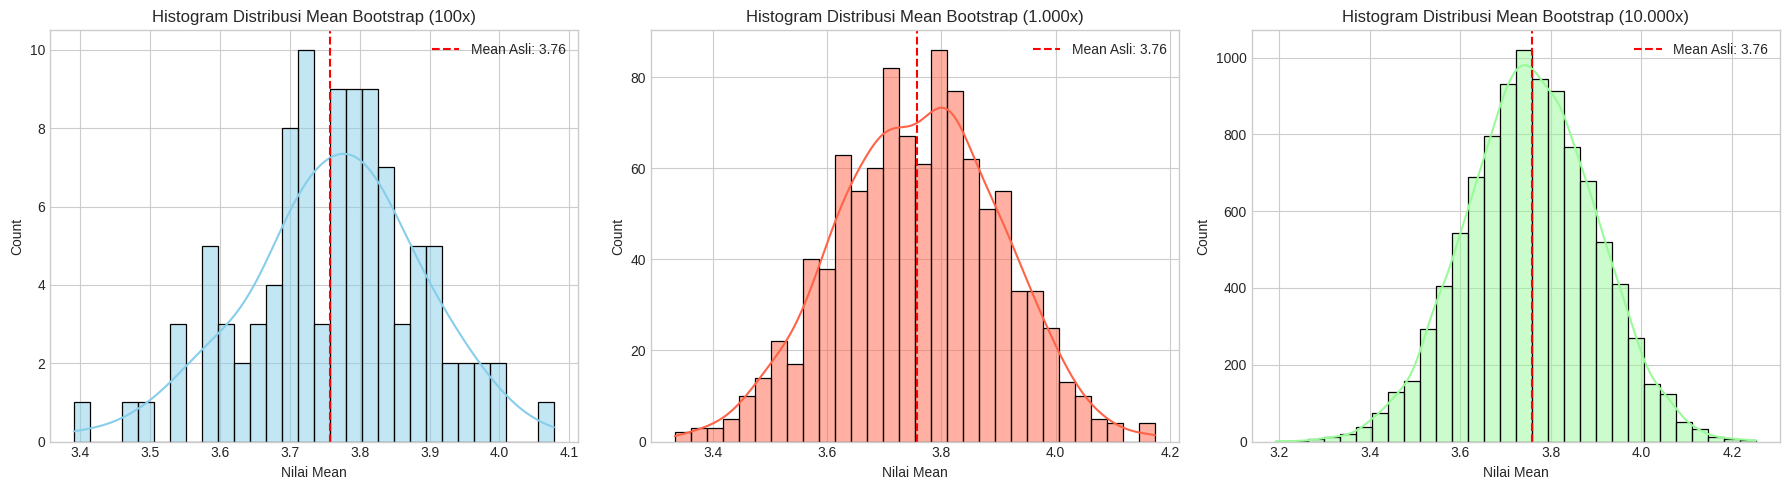

In [86]:
# 3. Visualisasi Hasil Bootstrap
# A. Histogram distribusi mean bootstrap
plt.figure(figsize=(18, 5))

# Plot 1: 100 kali
plt.subplot(1, 3, 1)
sns.histplot(m100, kde=True, color='skyblue', bins=30)
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean Asli: {data.mean():.2f}')
plt.title("Histogram Distribusi Mean Bootstrap (100x)")
plt.xlabel("Nilai Mean")
plt.legend()

# Plot 2: 1.000 kali
plt.subplot(1, 3, 2)
sns.histplot(m1000, kde=True, color='tomato', bins=30)
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean Asli: {data.mean():.2f}')
plt.title("Histogram Distribusi Mean Bootstrap (1.000x)")
plt.xlabel("Nilai Mean")
plt.legend()

# Plot 3: 10.000 kali
plt.subplot(1, 3, 3)
sns.histplot(m10000, kde=True, color='palegreen', bins=30)
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean Asli: {data.mean():.2f}')
plt.title("Histogram Distribusi Mean Bootstrap (10.000x)")
plt.xlabel("Nilai Mean")
plt.legend()

plt.tight_layout()
plt.show()

/tmp/ipython-input-459/4247852775.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([m100, m1000, m10000], labels=['BS 100', 'BS 1000', 'BS 10000'])


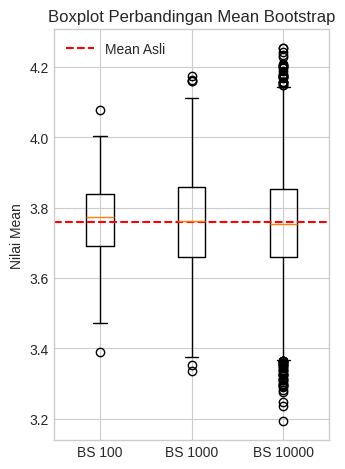

In [87]:
# B. Boxplot mean bootstrap
plt.subplot(1, 2, 2)
plt.boxplot([m100, m1000, m10000], labels=['BS 100', 'BS 1000', 'BS 10000'])
plt.axhline(data.mean(), color='red', linestyle='--', label='Mean Asli')
plt.title("Boxplot Perbandingan Mean Bootstrap")
plt.ylabel("Nilai Mean")
plt.legend()

plt.tight_layout()
plt.show()

Perbandingan Hasil Bootstrap

Peningkatan jumlah iterasi dalam simulasi bootstrap menghasilkan transformasi struktural yang signifikan pada distribusi sampling. Pada skala 100 iterasi, distribusi rata-rata sampel cenderung bersifat diskrit, kasar, dan tidak beraturan, yang mengindikasikan bahwa jumlah pengulangan tersebut belum memadai untuk merepresentasikan ruang kemungkinan statistik secara komprehensif. Sebaliknya, pada tingkat 10.000 iterasi, distribusi mengalami penghalusan (smoothing) dan secara progresif membentuk kurva lonceng simetris. Fenomena ini merupakan manifestasi dari Teorema Limit Pusat, di mana distribusi sampling akan mendekati distribusi normal yang ideal seiring bertambahnya jumlah replikasi.

In [88]:
# 4. Interval Kepercayaan 95%
def hitung_ci(data_bootstrap):
    lower = np.percentile(data_bootstrap, 2.5)
    upper = np.percentile(data_bootstrap, 97.5)
    return lower, upper

ci_100 = hitung_ci(m100)
ci_1000 = hitung_ci(m1000)
ci_10000 = hitung_ci(m10000)

data_ci = {
    'Bootstrap': ['100x', '1.000x', '10.000x'],
    'Batas Bawah (2.5%)': [ci_100[0], ci_1000[0], ci_10000[0]],
    'Batas Atas (97.5%)': [ci_100[1], ci_1000[1], ci_10000[1]],
    'Rentang (Width)': [ci_100[1]-ci_100[0], ci_1000[1]-ci_1000[0],
                        ci_10000[1]-ci_10000[0]]
}

df_ci = pd.DataFrame(data_ci)
print("Perbandingan Interval Kepercayaan 95%:")
print(df_ci.to_string(index=False))

Perbandingan Interval Kepercayaan 95%:
Bootstrap  Batas Bawah (2.5%)  Batas Atas (97.5%)  Rentang (Width)
     100x            3.512333            3.991350         0.479017
   1.000x            3.479317            4.029417         0.550100
  10.000x            3.469317            4.034667         0.565350


Perbandingan CI Bootstrap

Aspek stabilitas pada estimasi Interval Kepercayaan (CI) 95% juga sangat dipengaruhi oleh intensitas iterasi. Iterasi rendah (100x) menunjukkan volatilitas yang tinggi, di mana batas atas dan bawah persentil sering berubah secara signifikan jika simulasi diulang (random error). Namun, pada 10.000 iterasi, nilai CI mencapai titik konvergensi statistik, memberikan estimasi yang sangat stabil dan konsisten.

Mengenai rentang atau lebar (width) interval, pelebaran yang terjadi pada iterasi tinggi sebenarnya mencerminkan peningkatan presisi. Pada iterasi sedikit, simulasi sering kali gagal menangkap nilai-nilai ekstrem pada ekor distribusi (tails). Dengan 10.000 iterasi, simulasi mampu menjangkau variabilitas data secara lengkap, menghasilkan rentang interval yang lebih objektif dalam mencerminkan risiko data asli. Sebagai kesimpulan, meskipun 1.000 iterasi sudah mencukupi untuk analisis standar, penggunaan 10.000 iterasi tetap menjadi standar emas (gold standard) untuk menjamin hasil yang presisi.

Bagian C - Perbandingan dan Analisis
1. **Apakah mean bootstrap mendekati mean data asli?**
Ya, sangat mendekati. Karena bootstrap mengambil sampel dari data asli secara berulang, rata-rata dari ribuan simulasi tersebut secara statistik akan memusat di sekitar nilai rata-rata aslinya.
2. **Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?**
Terjadi perubahan tingkat kehalusan grafik. Pada 100 iterasi, grafiknya masih kasar dan "bergerigi". Namun, saat mencapai 1.000 hingga 10.000 iterasi, histogramnya menjadi sangat halus dan membentuk kurva lonceng sempurna (Normal), sesuai dengan Teorema Limit Pusat.
3. **Mana yang lebih stabil: 100, 1000, atau 10000?**
Iterasi 10.000x adalah yang paling stabil. Jika simulasi dijalankan ulang, angka yang dihasilkan pada 10.000 iterasi hampir tidak berubah (konvergen), sedangkan pada 100 atau 1.000 iterasi angkanya masih sering melompat-lompat atau fluktuatif.
4. **Apakah mean asli berada dalam interval kepercayaan (CI)?**
Ya, nilai rata-rata asli ditemukan berada di dalam rentang CI 95%. Ini membuktikan bahwa metode bootstrap yang kita gunakan berhasil menangkap nilai yang sebenarnya dengan tingkat kepercayaan yang tinggi.
5. **Mengapa satu data bisa muncul berkali-kali pada bootstrap?**
Ini karena prinsip pengambilan sampel dengan pengembalian (sampling with replacement). Setiap kali satu data diambil, data tersebut dimasukkan kembali ke "kantong" sehingga memiliki peluang untuk terambil lagi pada tarikan berikutnya dalam satu iterasi yang sama.

BAGIAN D: Kesimpulan
1. **Insight Utama EDA**
Fitur Petal (kelopak dalam) adalah pembeda paling kuat untuk mengenali spesies Iris. EDA juga menunjukkan bahwa meskipun datanya bersih, ada perbedaan karakter yang sangat ekstrem antara spesies Setosa dengan dua spesies lainnya.

2. **Karakteristik Spesies**
Setosa berukuran kecil dan terisolasi, Versicolor berada di tengah, dan Virginica adalah yang terbesar namun memiliki variasi ukuran yang paling lebar.

3. **Manfaat Bootstrap**
Kita bisa melakukan estimasi statistik dan mengukur tingkat ketidakpastian (Interval Kepercayaan) tanpa harus memiliki data populasi yang besar atau asumsi distribusi yang kaku.

4. **Jumlah Bootstrap yang Cukup**
Berdasarkan praktik ini, 10.000 kali adalah jumlah yang paling ideal karena memberikan hasil yang stabil, presisi, dan tidak lagi berubah-ubah saat simulasi diulang.